[Home](../../README.md)

### Model Evaluation

This is a demonstration of evaluating a model.

#### Step 1

Load the required dependencies.


In [47]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2

Load the model for testing

In [48]:
filename = 'my_saved_model_v1.sav'
model_A = pickle.load(open(filename, 'rb'))


(Optional) Load a second model if you want to do comparative testing

In [49]:
filename = 'my_saved_model_v1.sav'
model_B = pickle.load(open(filename, 'rb'))

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [50]:
x_col = 'start'
testing_data = pd.read_csv("2.4.1.NASCAR testing_data.csv")
x_test = np.array(testing_data[x_col]).reshape(-1,1)
y_test = np.array(testing_data['fin'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

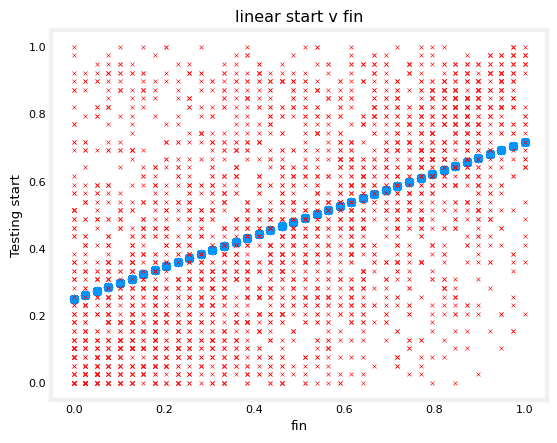

In [51]:
y_pred = model_A.predict(x_test)
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r', s=.1)
plt.title("linear start v fin")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'fin')
plt.show()

#### Step 6

Use the 'score' method of the `LinearRegression` class to return a score based evaluation of the models accuracy or performance.

In [52]:
test_score = model_A.score(x_test, y_test)
print(f'Training data score: {test_score}')

Training data score: 0.23233040283106865


so basically its not very good since the score is 0.2 but i think thats because i just chose data that didnt have much correlation

#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [53]:
table = pd.DataFrame({
    testing_data.columns[0]: x_test.flatten(),  # Flatten x for easy display
    testing_data.columns[1]: y_test,
    'Predicted result':model_A.predict(x_test),
    'Loss' : abs(model_A.predict(x_test).round(2) - y_test)**2
})
print(table)
cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()

print(f"The cost or average loss of this model is {cost}")

           fin     start  Predicted result      Loss
0     0.435897  0.333333          0.454100  0.013611
1     0.794872  0.743590          0.621805  0.015274
2     0.846154  0.820513          0.645763  0.029075
3     0.846154  0.871795          0.645763  0.049193
4     0.205128  0.769231          0.346290  0.175754
...        ...       ...               ...       ...
2827  0.358974  0.333333          0.418163  0.007511
2828  0.897436  0.871795          0.669721  0.040721
2829  0.948718  0.769231          0.693679  0.006278
2830  0.076923  0.205128          0.286395  0.007203
2831  0.102564  0.256410          0.298374  0.001900

[2832 rows x 4 columns]
The cost or average loss of this model is 0.030990991491064827


You may want to do some manual predictions to understand your model.

In [54]:
print(model_A.predict([[0.1]]))
print(model_A.predict([[1]]))

[0.29717607]
[0.71763698]


#### Step 8

Evaluate the X axis intercept and gradient or coefficient of your model by using the getter methods to return the intercept and coefficient from my_model() object.

In [55]:
print(f'X Axis intercept: {model_A.intercept_}')
print(f'Coefficient: {model_A.coef_}')

X Axis intercept: 0.25045819319464513
Coefficient: [0.46717879]


#### Step 9. Multiple Variable Linear Regression

You should be able to understand the code snippets with less guidelines.

In [56]:
filename = 'my_saved_model_v2.sav'
model_C = pickle.load(open(filename, 'rb'))

In [57]:
mx_col = [
    "start",
    "manu_avg_fin",
    "manu_avg_fin_track",
    "manu_track_delta",
    "avg_fin_track",
]
testing_data = pd.read_csv("2.4.1.NASCAR testing_data.csv")
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['fin'])

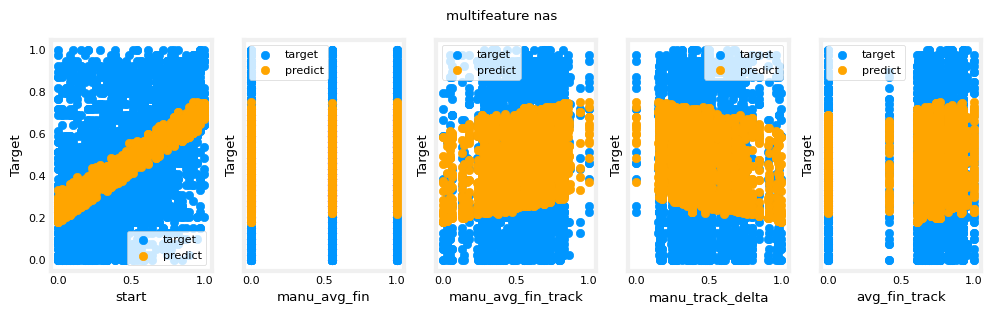

In [58]:
my_pred = model_C.predict(mx_test)

# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,len(mx_col),figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:,i],my_test, label = 'target')
    ax[i].set_xlabel(mx_col[i])
    ax[i].scatter(mx_test[:,i],my_pred,color="orange", label = 'predict')
    ax[i].set_ylabel("Target"); ax[i].legend();
fig.suptitle("multifeature nas")
plt.show()

In [59]:
test_score = model_C.score(mx_test, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.23549321882736862


single feature - 0.23233040283106865

multi - 0.23549321882736862

it is just barely better (but still not very good)

In [60]:
# manual predictions testing
# [start, manu_avg_fin, manu_avg_fin_track, manu_track_delta, avg_fin_track]

# Example: Toyota starting P1 at Daytona (scaled values from NASCAR data scaled csv)
print(model_C.predict([[0.0, 0.0, 0.264, 0.490, 0.0]]))

# Example: Ford starting P5 at Daytona
print(model_C.predict([[0.103, 0.558, 0.280, 0.473, 0.0]]))

# Example: Chevrolet starting P10 at Atlanta
print(model_C.predict([[0.231, 1.0, 0.634, 0.329, 0.616]]))

print(f"Coefficient: {model_C.coef_}")

[0.19242297]
[0.22244594]
[0.19549758]
Coefficient: [ 4.52309539e-01 -2.74248814e-02  1.62047373e+02  1.52589400e+02
 -5.75724327e+01]


In [61]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_C.predict(mx_test)
data['Loss'] = abs(model_C.predict(mx_test).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 0.030861465379229396
         start  manu_avg_fin  manu_avg_fin_track  manu_track_delta  \
0     0.435897      1.000000            0.792548          0.179826   
1     0.794872      0.558128            0.479415          0.505398   
2     0.846154      0.558128            0.659729          0.351161   
3     0.846154      0.000000            0.047126          0.963986   
4     0.205128      0.558128            0.461775          0.521835   
...        ...           ...                 ...               ...   
2827  0.358974      1.000000            0.571002          0.480261   
2828  0.897436      0.558128            0.489307          0.513043   
2829  0.948718      1.000000            0.736124          0.251205   
2830  0.076923      0.000000            0.391150          0.587932   
2831  0.102564      1.000000            0.472368          0.614621   

      avg_fin_track    Target  Predicted result      Loss  
0          0.663443  0.333333       

In [62]:
print(f'X Axis intercept: {model_C.intercept_}')
print(f'Coefficient: {model_C.coef_}')

X Axis intercept: -117.3568891821462
Coefficient: [ 4.52309539e-01 -2.74248814e-02  1.62047373e+02  1.52589400e+02
 -5.75724327e+01]


#### Step 10. Polynomial Linear Regression

You should be able to understand the code snippets with less guidelines.

In [63]:
model_filename = 'my_saved_model_v3.sav'
poly_filename = 'my_saved_poly_v3.pkl'

model_D = pickle.load(open(model_filename, 'rb'))
poly = pickle.load(open(poly_filename, 'rb'))

In [64]:
mx_col = [
    "start",
    "manu_avg_fin",
    "manu_avg_fin_track",
    "manu_track_delta",
    "avg_fin_track",
]
testing_data = pd.read_csv("2.4.1.NASCAR testing_data.csv")
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['fin'])

In [65]:
poly_features = poly.transform(mx_test)

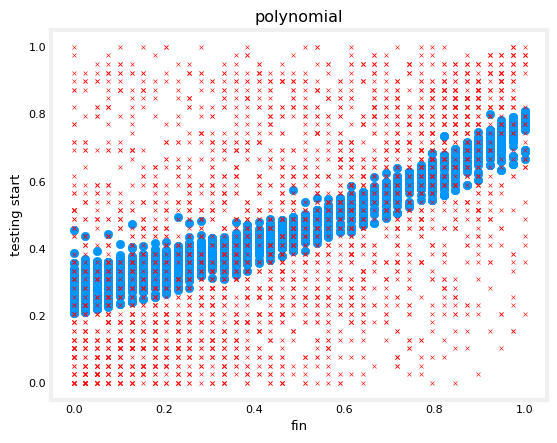

In [66]:
y_pred = model_D.predict(poly_features)

plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r', s=.1)
plt.title("polynomial")
plt.ylabel(f'testing {x_col}')
plt.xlabel(f'fin')
plt.show()

In [67]:
test_score = model_D.score(poly_features, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.24165876901452343


single feature - 0.23233040283106865

multi - 0.23549321882736862

polynomial - 0.24542914991652665

it is still just barely better (but still not very good)

In [68]:
example = np.array(
    # "start",
    # "manu_avg_fin",
    # "manu_avg_fin_track",
    # "manu_track_delta",
    # "avg_fin_track",
    [[0.103, 0.558, 0.280, 0.473, 0.0]],
)  # scaled Ford @ Daytona P5 example
new_poly_feature = poly.fit_transform(example)
print(model_D.predict(new_poly_feature))

[1.51999886]


its here that i realised that since its trained on manu_avg_fin, manu_avg_fin_track, manu_track_delta avg_fin_track and i want the user to just input manufacturer, track and starting position, i would have to make a lookup system in the api or interface or something so that when the user inputs the stuff it grabs the values associated with that track and manufacturer so the model actually gets what it was trained on

i also need to scale the values when theyre inputted and unscale it back

In [69]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_D.predict(poly_features)
data['Loss'] = abs(model_D.predict(poly_features).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 0.03062311701619883
         start  manu_avg_fin  manu_avg_fin_track  manu_track_delta  \
0     0.435897      1.000000            0.792548          0.179826   
1     0.794872      0.558128            0.479415          0.505398   
2     0.846154      0.558128            0.659729          0.351161   
3     0.846154      0.000000            0.047126          0.963986   
4     0.205128      0.558128            0.461775          0.521835   
...        ...           ...                 ...               ...   
2827  0.358974      1.000000            0.571002          0.480261   
2828  0.897436      0.558128            0.489307          0.513043   
2829  0.948718      1.000000            0.736124          0.251205   
2830  0.076923      0.000000            0.391150          0.587932   
2831  0.102564      1.000000            0.472368          0.614621   

      avg_fin_track    Target  Predicted result      Loss  
0          0.663443  0.333333        

#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.